## Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load in data

In [5]:
#First, upload the data into the colab environment

df = pd.read_csv('A2_Data_Succession.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,department,salary,left
0,0.69,0.59,4,266,4,0,0,technical,medium,0
1,0.68,0.54,4,146,4,0,1,marketing,medium,0
2,0.59,0.58,2,267,3,0,0,sales,medium,0
3,0.73,0.61,4,260,2,1,0,sales,low,0
4,0.49,0.40,2,148,2,1,1,management,high,0


## Let's build a predictive model

First, split the data

In [6]:
#split into train/test
from sklearn.model_selection import train_test_split
X = df.drop(columns=['left']) #drop the target variable
y = df['left']
# y = y.map({' N': 0, ' Y': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(y_test.head())

X_train shape: (7000, 9)
y_train shape: (7000,)
X_test shape: (3000, 9)
y_test shape: (3000,)
6252    0
4684    1
1731    0
4742    0
4521    0
Name: left, dtype: int64


Encode categorical variables

In [7]:
from sklearn.preprocessing import OneHotEncoder


# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(exclude='object').columns

# Initialize OneHotEncoder
# handle_unknown='ignore' will set new categories to all zeros
# drop='first' implements dummy encoding (k-1 categories)
ohe = OneHotEncoder(handle_unknown='error', sparse_output=False, drop='first')

# Fit and transform on training data
X_train_encoded_cat = ohe.fit_transform(X_train[categorical_cols])
X_train_encoded_cat_df = pd.DataFrame(X_train_encoded_cat, columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
X_train_encoded = pd.concat([X_train[numerical_cols], X_train_encoded_cat_df], axis=1)

# Transform test data
X_test_encoded_cat = ohe.transform(X_test[categorical_cols])
X_test_encoded_cat_df = pd.DataFrame(X_test_encoded_cat, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)
X_test_encoded = pd.concat([X_test[numerical_cols], X_test_encoded_cat_df], axis=1)



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)


# Train the model with encoded data
rf.fit(X_train_encoded, y_train)

print("Random Forest model trained successfully with OneHotEncoder!")

Random Forest model trained successfully with OneHotEncoder!


[[0.99 0.01]
 [0.   1.  ]
 [0.98 0.02]
 ...
 [0.   1.  ]
 [0.98 0.02]
 [0.01 0.99]]


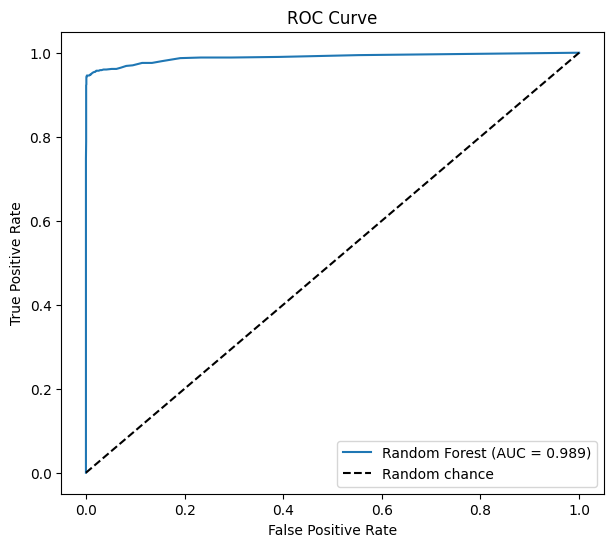

In [10]:
from sklearn.metrics import roc_curve,roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
#For evaluation, predictions are made on the TEST set
#Never only show performance on the training set because you might have overfitted
# Get predicted probabilities for the positive class
# Ensure rf_model is defined, which it should be from the previous cell's successful run.
print(rf.predict_proba(X_test_encoded))
#This outputs an array of size (n_test, 2), where the first column gives the predicted probability
#of Sale_Y = 0, and the second column the probability of Sale_Y = 1
y_proba = rf.predict_proba(X_test_encoded)[:, 1]

# Compute ROC curve using y_test (which was converted to int in the previous cell)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)


# Plot ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

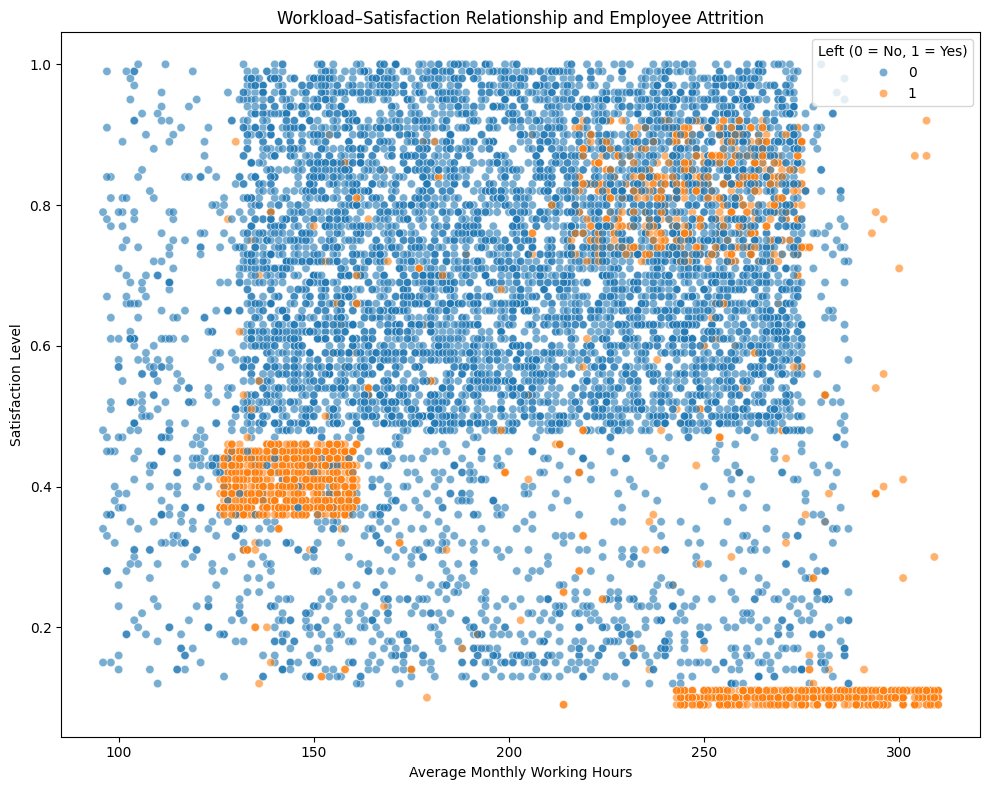

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
# df = pd.read_csv("A2_Data_Succession.csv")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x="average_montly_hours",
    y="satisfaction_level",
    hue="left",
    alpha=0.6
)

plt.xlabel("Average Monthly Working Hours")
plt.ylabel("Satisfaction Level")
plt.title("Workload–Satisfaction Relationship and Employee Attrition")
plt.legend(title="Left (0 = No, 1 = Yes)")

plt.tight_layout()
plt.savefig("workload_satisfaction_attrition.png", dpi=300, bbox_inches="tight")

plt.show()


Get other metrics (think about the threshold!)

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def score_function(y_true, y_proba,threshold):
  y_pred = (y_proba >= threshold).astype(int)
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  return accuracy, precision, recall, f1

In [12]:
#find best F1 using cross-validation --> NEVER do this on the test set (introduces bias)
from sklearn.model_selection import StratifiedKFold
#split data into five folds while keeping y distribution the same in each split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#we use 5 folds and manually fill probs train
probs_cross_val = np.zeros_like(y_train, dtype=float) #first create an array of zero values
#we will now fill this array with predicted probabilities using cross_validation
for train_idx, val_idx in cv.split(X_train_encoded, y_train):
    cross_val_rf = RandomForestClassifier(random_state=42)
    cross_val_rf.fit(X_train_encoded.iloc[train_idx], y_train.iloc[train_idx])#train a new RF each time
    probs_cross_val[val_idx] = cross_val_rf.predict_proba(X_train_encoded.iloc[val_idx])[:, 1]

#now we have the predictions using cross_validation on the whole training set
#find best threshold using these predictions
current_best_f1 = 0
thresholds = np.linspace(0, 1, 100) #create a list of possible thresholds from 0 to 1
for threshold in thresholds:  #go over all the thresholds and pick the the one with highest F1
    accuracy, precision, recall, f1 = score_function(y_train, probs_cross_val,threshold)
    if f1 > current_best_f1:
        current_best_f1 = f1
        current_best_threshold = threshold

best_threshold = current_best_threshold
print(f"Best threshold: {current_best_threshold}")
#use threshold to make predictions on test data
y_proba = rf.predict_proba(X_test_encoded)[:, 1]
#calculate scores and print
accuracy, precision, recall, f1 = score_function(y_test, y_proba,best_threshold)
print("accuracy",accuracy)
print("precision",precision)
print("recall",recall)
print("f1",f1)



Best threshold: 0.4444444444444445
accuracy 0.9846666666666667
precision 0.9880597014925373
recall 0.9457142857142857
f1 0.9664233576642336


## Optional: do a grid-search to optimize hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

#optional
# Define a grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
}

# Set up GridSearchCV (cross-validation)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',     # or 'f1', 'accuracy_score' depending on your task
    cv=3,                   # 3-fold cross-validation within training data
    n_jobs=-1,
    verbose=2
)

# Run grid search on the *training* data
grid_search.fit(X_train_encoded, y_train)

# Retrieve the best model
best_rf = grid_search.best_estimator_

print("Best Parameters found by Grid Search:")
print(grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters found by Grid Search:
{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}


Now we can again optimize the threshold with the best model

In [ ]:
#same code as above but change how cross_val_rf is initialized and best_rf for test set predictions
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#we use 5 folds and manually fill probs train
probs_cross_val = np.zeros_like(y_train, dtype=float) #first create an array of zero values
#we will now fill this array with predicted probabilities using cross_validation
for train_idx, val_idx in cv.split(X_train_encoded, y_train):
    #this changed
    cross_val_rf = RandomForestClassifier(**grid_search.best_params_,random_state=42)
    cross_val_rf.fit(X_train_encoded.iloc[train_idx], y_train.iloc[train_idx])#train a new RF each time
    probs_cross_val[val_idx] = cross_val_rf.predict_proba(X_train_encoded.iloc[val_idx])[:, 1]

#now we have the predictions using cross_validation on the whole training set
#find best threshold using these predictions
current_best_f1 = 0
thresholds = np.linspace(0, 1, 100) #create a list of possible thresholds from 0 to 1
for threshold in thresholds:  #go over all the thresholds and pick the the one with highest F1
    accuracy, precision, recall, f1 = score_function(y_train, probs_cross_val,threshold)
    if f1 > current_best_f1:
        current_best_f1 = f1
        current_best_threshold = threshold

best_threshold = current_best_threshold
print(f"Best threshold: {current_best_threshold}")
#use threshold to make predictions on test data
#use the best_rf here!
y_proba = best_rf.predict_proba(X_test_encoded)[:, 1]
#calculate scores and print
accuracy, precision, recall, f1 = score_function(y_test, y_proba,best_threshold)
print("accuracy",accuracy)
print("precision",precision)
print("recall",recall)
print("f1",f1)


Best threshold: 0.36363636363636365
accuracy 0.8619447779111644
precision 0.7643979057591623
recall 0.6759259259259259
f1 0.7174447174447175


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#get all the metrics for best_rf with threshold 0.5
pred_proba = best_rf.predict_proba(X_test_encoded)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
roc_auc = roc_auc_score(y_test, pred_proba)

accuracy, precision, recall, f1 = score_function(y_test, pred_proba,0.5)
print("AUC",roc_auc)
print("other metrics")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

AUC 0.9109790503631671
other metrics
Accuracy: 0.8547418967587035
Precision: 0.8275862068965517
Recall: 0.5555555555555556
F1: 0.6648199445983379


As you can see, you can go quite far in optimizing every little thing. Importantly, there is always a trade-off in how much time you spend to get that 1% more AUC. For the assignment: no need to go super deep into the optimization, but show that you know that this exists and how this can be done.

Above I used cross-validation. Note that you can also use a separate validation set, which simplifies the code by a lot. This is equally valid, but a little bit less data efficient. If you want to use a validation set for the assignment, this is also fine.

What's cool about sklearn is that you can now just copy paste this and only change the model. All methods have the same fit-predict (sklearn style) setup.

## Foundational models for tabular data (optional)

**Important**: For this you need a GPU. You can do this by clicking on the little arrow next to RAM and Disk and selecting "change runtime type". Then select a GPU or TPU. Once you did this, you will need to upload the data again and then run all the loading and preprocessing of the data again (easiest way is to just run all and wait a little bit)

In [ ]:
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.9/551.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd
import numpy as np

# Initialize the TabPFN Classifier

tabpfn_model = TabPFNClassifier.create_default_for_version(ModelVersion.V2)
# Train the model with encoded data (convert to numpy arrays for TabPFN)
tabpfn_model.fit(X_train_encoded, y_train)

print("TabPFN model trained successfully with OneHotEncoder!")

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN model trained successfully with OneHotEncoder!


[[0.9988882  0.00111183]
 [0.97753906 0.02246094]
 [0.6713867  0.32861328]
 ...
 [0.98663574 0.01336425]
 [0.2734375  0.7265625 ]
 [0.9093462  0.09065381]]


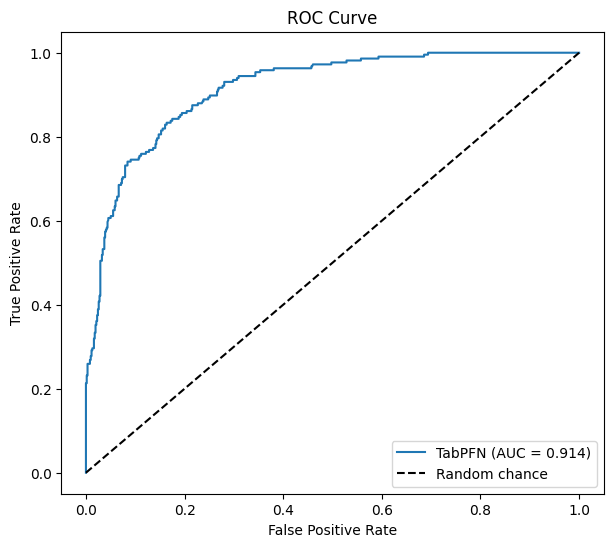

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
#For evaluation, predictions are made on the TEST set
#Never only show performance on the training set because you might have overfitted
# Get predicted probabilities for the positive class
# Ensure tabpfn_model is defined, which it should be from the previous cell's successful run.
print(tabpfn_model.predict_proba(X_test_encoded))
#This outputs an array of size (n_test, 2), where the first column gives the predicted probability
#of Sale_Y = 0, and the second column the probability of Sale_Y = 1
y_proba = tabpfn_model.predict_proba(X_test_encoded)[:, 1]

# Compute ROC curve using y_test_encoded for consistency
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)


# Plot ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"TabPFN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#other metrics (note I just used 0.5, you can still tune this threshold!)
accuracy, precision, recall, f1 = score_function(y_test, y_proba,0.5)
print("AUC",roc_auc)
print("accuracy",accuracy)
print("precision",precision)
print("recall",recall)
print("f1",f1)


AUC 0.9144794105288433
accuracy 0.8619447779111644
precision 0.8258064516129032
recall 0.5925925925925926
f1 0.6900269541778976


The performance out of the box is really good, even slightly better than a finetuned Random Forest!

# Code with separate validation set (optional)
This is the same code to train the random forest and optimize the hyperparamers. The difference is that we will now just use a separate validation set

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training (60%) and a temporary set (40%)
X_train_new, X_temp, y_train_new, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Split the temporary set (40%) into validation (20%) and test (20%) -- 0.5 of 40% is 20%
X_val, X_test_new, y_val, y_test_new = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

X_train_new shape: (1665, 14)
y_train_new shape: (1665,)
X_val shape: (555, 14)
y_val shape: (555,)
X_test_new shape: (555, 14)
y_test_new shape: (555,)


## Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# 1. Identify categorical and numerical columns based on X_train_new
categorical_cols_new = X_train_new.select_dtypes(include='object').columns
numerical_cols_new = X_train_new.select_dtypes(exclude='object').columns

# 2. Initialize OneHotEncoder
ohe_new = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# 3. Fit and transform on training data
X_train_encoded_cat_new = ohe_new.fit_transform(X_train_new[categorical_cols_new])
X_train_encoded_cat_df_new = pd.DataFrame(X_train_encoded_cat_new, columns=ohe_new.get_feature_names_out(categorical_cols_new), index=X_train_new.index)
X_train_encoded_new = pd.concat([X_train_new[numerical_cols_new], X_train_encoded_cat_df_new], axis=1)

# 5. Transform validation data
X_val_encoded_cat = ohe_new.transform(X_val[categorical_cols_new])
X_val_encoded_cat_df = pd.DataFrame(X_val_encoded_cat, columns=ohe_new.get_feature_names_out(categorical_cols_new), index=X_val.index)
# 6. Concatenate numerical and encoded categorical for validation
X_val_encoded = pd.concat([X_val[numerical_cols_new], X_val_encoded_cat_df], axis=1)

# 7. Transform test data
X_test_encoded_cat_new = ohe_new.transform(X_test_new[categorical_cols_new])
X_test_encoded_cat_df_new = pd.DataFrame(X_test_encoded_cat_new, columns=ohe_new.get_feature_names_out(categorical_cols_new), index=X_test_new.index)
# 8. Concatenate numerical and encoded categorical for test
X_test_encoded_new = pd.concat([X_test_new[numerical_cols_new], X_test_encoded_cat_df_new], axis=1)

# 9. Print shapes
print(f"X_train_encoded_new shape: {X_train_encoded_new.shape}")
print(f"X_val_encoded shape: {X_val_encoded.shape}")
print(f"X_test_encoded_new shape: {X_test_encoded_new.shape}")

X_train_encoded_new shape: (1665, 55)
X_val_encoded shape: (555, 55)
X_test_encoded_new shape: (555, 55)


## Hyperparameter Tuning with Validation Set (Manual Grid Search)

Implement a manual grid search. It will iterate through combinations of hyperparameters for RandomForestClassifier. For each combination, a model will be trained on `X_train_encoded_new` and its performance (e.g., F1-score or AUC) will be evaluated on `X_val_encoded`. The best hyperparameters and the corresponding model will be stored.


Here, the threshold is optimized jointly with the other parameters. Previously, this was done separately. Both are reasonable

In [ ]:
import itertools
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Define the param_grid dictionary
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}

# 2. Initialize variables to store the best results
best_f1_score = 0
best_params = {}
best_rf_model_val_tuned = None
best_threshold_val_tuned = 0.5 # Default threshold

# Generate all hyperparameter combinations
hyperparameter_combinations = list(itertools.product(param_grid['n_estimators'],
                                                     param_grid['max_depth'],
                                                     param_grid['min_samples_leaf']))

print(f"Starting grid search with {len(hyperparameter_combinations)} combinations...")

# Iterate through each hyperparameter_combination
for n_estimators, max_depth, min_samples_leaf in hyperparameter_combinations:
    current_params = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_leaf': min_samples_leaf,
    }

    # Initialize a RandomForestClassifier with current_params
    rf_current = RandomForestClassifier(random_state=42, **current_params)

    # Train the model on the training data
    rf_current.fit(X_train_encoded_new, y_train_new)

    # Predict probabilities on the validation set
    y_val_proba = rf_current.predict_proba(X_val_encoded)[:, 1]

    # Optimize the classification threshold for the current model on the validation set
    current_best_f1_val = 0
    current_threshold_for_f1 = 0.5 # Reset for each model
    thresholds = np.linspace(0.01, 0.99, 100) # Create a list of possible thresholds from 0.01 to 0.99

    for threshold in thresholds:
      #get f1 for threshold
        f1 = f1_score(y_val, (y_val_proba >= threshold).astype(int))
        if f1 > current_best_f1_val:
            current_best_f1_val = f1
            current_threshold_for_f1 = threshold

    # Check if this model is the best so far
    if current_best_f1_val > best_f1_score:
        best_f1_score = current_best_f1_val
        best_params = current_params
        best_rf_model_val_tuned = rf_current # Store the trained model
        best_threshold_val_tuned = current_threshold_for_f1

print("Grid search complete!")
print(f"Best F1-score on validation set: {best_f1_score:.4f}")
print(f"Best Hyperparameters: {best_params}")
print(f"Best Threshold for F1-score: {best_threshold_val_tuned:.4f}")

Starting grid search with 27 combinations...
Grid search complete!
Best F1-score on validation set: 0.7468
Best Hyperparameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 4}
Best Threshold for F1-score: 0.3268


The previous manual grid search identified the best hyperparameters and an optimal threshold using the validation set. Now, the subtask requires evaluating the performance of this `best_rf_model_val_tuned` on the unseen test set (`X_test_encoded_new`, `y_test_new`) using the `best_threshold_val_tuned` and visualize the ROC curve.

**Important**: we cannot directly compare these numbers with the metrics from the previous section with cross-validation.


**Why?** The test set is different (smaller + contains different samples)!




Performance on Test Set with Best Hyperparameters and Optimal Threshold (0.3268):
AUC: 0.9057
Accuracy: 0.8396
Precision: 0.6369
Recall: 0.7576
F1-score: 0.6920


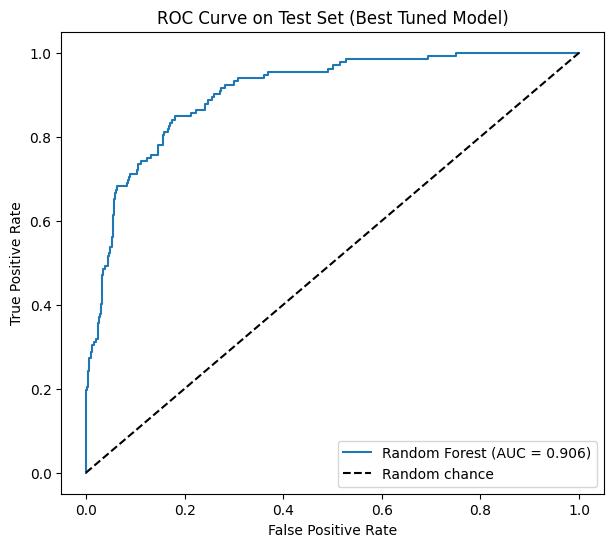

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Predict probabilities on the test set using the best model found during grid search
y_test_proba = best_rf_model_val_tuned.predict_proba(X_test_encoded_new)[:, 1]

# Calculate evaluation metrics using the best threshold found on the validation set
accuracy, precision, recall, f1 = score_function(y_test_new, y_test_proba, best_threshold_val_tuned)

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test_new, y_test_proba)

print(f"\nPerformance on Test Set with Best Hyperparameters and Optimal Threshold ({best_threshold_val_tuned:.4f}):")
print(f"AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Plot ROC curve for the best model on the test set
fpr, tpr, thresholds = roc_curve(y_test_new, y_test_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (Best Tuned Model)")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1) Load data
df = pd.read_csv("A2_Data_Succession.csv")

# 2) Target and features
y = df["left"]
X = df.drop(columns=["left"])

# 3) One-hot / dummy encoding ONLY (as instructed)
X = pd.get_dummies(X, drop_first=True)

# 4) Train-test split (stratified because class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(
        random_state=42, n_estimators=300, max_depth=None, min_samples_leaf=2, n_jobs=-1
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    # For ROC-AUC we need probabilities (or decision scores)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }
    results.append(row)

# 6) Results table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(results_df.to_string(index=False))

# 7) Confusion matrix for the best model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_pred = best_model.predict(X_test)

print("\nBest model:", best_model_name)
print("Confusion matrix:\n", confusion_matrix(y_test, best_pred))
print("\nClassification report:\n", classification_report(y_test, best_pred, digits=3))


              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest     0.974   0.988399 0.900634 0.942478 0.983908
      Decision Tree     0.971   0.972665 0.902748 0.936404 0.968537
Logistic Regression     0.794   0.615094 0.344609 0.441734 0.833020

Best model: Random Forest
Confusion matrix:
 [[1522    5]
 [  47  426]]

Classification report:
               precision    recall  f1-score   support

           0      0.970     0.997     0.983      1527
           1      0.988     0.901     0.942       473

    accuracy                          0.974      2000
   macro avg      0.979     0.949     0.963      2000
weighted avg      0.974     0.974     0.974      2000

